Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Load Dataset

In [2]:
df = pd.read_csv("Iris Dataset.csv")

print(df.head())
print(df.info())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


Prepare Data

In [3]:
X = df.drop(["Species", "Id"], axis=1)
y = df["Species"]

Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Normalize Features

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Find Best K

In [6]:
accuracies = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"K={k}, Accuracy={acc:.4f}")

K=1, Accuracy=0.9667
K=2, Accuracy=0.9333
K=3, Accuracy=0.9333
K=4, Accuracy=0.9333
K=5, Accuracy=0.9333
K=6, Accuracy=0.9333
K=7, Accuracy=0.9667
K=8, Accuracy=0.9333
K=9, Accuracy=0.9667
K=10, Accuracy=0.9667
K=11, Accuracy=0.9667
K=12, Accuracy=0.9667
K=13, Accuracy=0.9667
K=14, Accuracy=0.9333
K=15, Accuracy=0.9667
K=16, Accuracy=0.9667
K=17, Accuracy=0.9667
K=18, Accuracy=0.9667
K=19, Accuracy=0.9667
K=20, Accuracy=0.9667


Plot K vs Accuracy

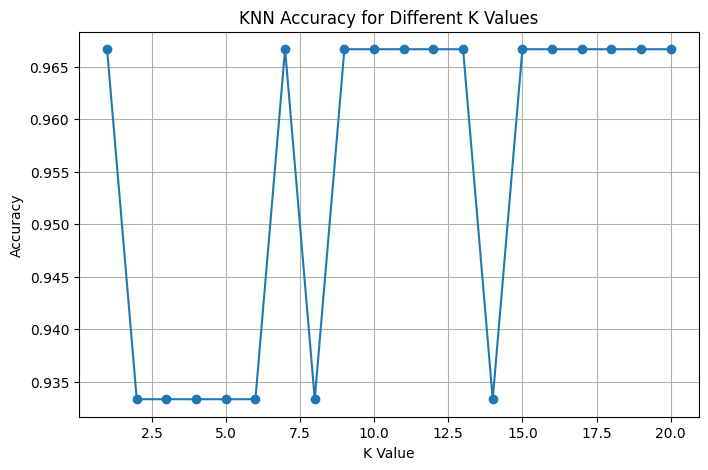

In [7]:
plt.figure(figsize=(8,5))
plt.plot(range(1,21), accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.grid(True)
plt.show()

Final Model

In [8]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

Evaluation

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



Decision Boundary Visualization

In [10]:
X_vis = df[['PetalLengthCm', 'PetalWidthCm']]
y_vis = df['Species']

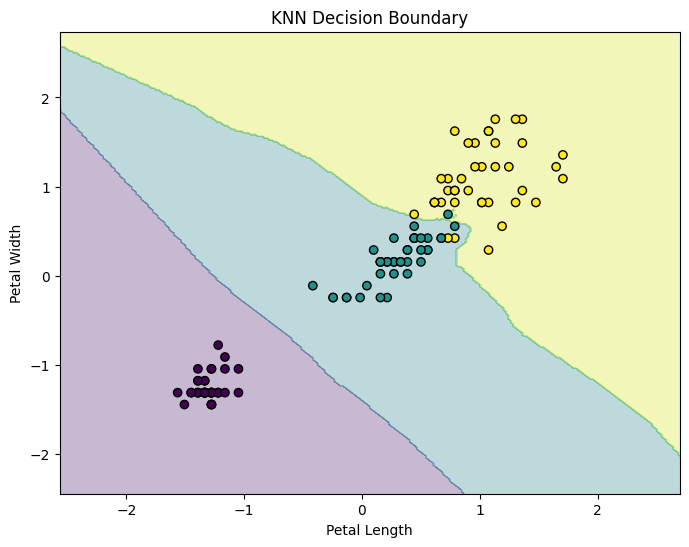

In [11]:
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import ListedColormap

le = LabelEncoder()
y_encoded = le.fit_transform(y_vis)

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vis, y_encoded,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train_v = scaler.fit_transform(X_train_v)

knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_train_v, y_train_v)

x_min, x_max = X_train_v[:,0].min()-1, X_train_v[:,0].max()+1
y_min, y_max = X_train_v[:,1].min()-1, X_train_v[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_train_v[:,0],
    X_train_v[:,1],
    c=y_train_v,
    edgecolor='k'
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("KNN Decision Boundary")
plt.show()